
# Weighted NPLM permutation tests on Gaussian toys

This notebook is a CPU-friendly smoke test for `EventWeightedCrossEntropyLoss` inside `falkon.LogisticFalkon`.

It runs two permutation tests using an NPLM-like statistic:

1. **Null test:** reference and data features are drawn from the same Gaussian, but the two classes use different positive event-weight distributions. The permutation p-value should not be systematically small.
2. **Alternative test:** reference and data features are drawn from shifted Gaussians, again with positive event weights. The permutation p-value should be small.

The permutation used here keeps the **class slots and their weights fixed**, and shuffles only the feature vectors among those slots. This is intentional: it tests whether the feature distribution is associated with the class label after conditioning on the class-specific weight pattern.

For quick laptop checks, start with `N_PERM = 25`. Increase to `100` or `200` when you want a more stable p-value estimate.


In [1]:

import sys
from pathlib import Path


def add_repo_root_to_path():
    """Find a parent directory containing nplm/ and add it to sys.path."""
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (candidate / "nplm").is_dir():
            if str(candidate) not in sys.path:
                sys.path.insert(0, str(candidate))
            print(f"Using repo root: {candidate}")
            return candidate
    print("Could not find an nplm/ folder above the current directory.")
    print("If imports fail, set REPO_ROOT manually and add it to sys.path.")
    return None


REPO_ROOT = add_repo_root_to_path()


Using repo root: /home/marcol/kernel-nplm


In [2]:

import math
import time
from dataclasses import dataclass
from typing import Optional

import numpy as np
import torch
import matplotlib.pyplot as plt

import falkon
from falkon.options import FalkonOptions

# This assumes your nplm/__init__.py exposes EventWeightedCrossEntropyLoss:
#   from .event_weighted_cross_entropy import EventWeightedCrossEntropyLoss
from nplm import EventWeightedCrossEntropyLoss

print("torch:", torch.__version__)
print("falkon:", getattr(falkon, "__version__", "unknown"))


/data/marcol/anaconda3/envs/flk_torch113_cu116/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch: 1.13.0
falkon: 0.8.4


In [3]:

# Laptop-friendly defaults.
# Increase N_PERM to 100 or 200 for a more stable permutation distribution.

DTYPE = torch.float64
N_REF = 400
N_DATA = 400
N_PERM = 200

# Falkon hyperparameters chosen to be small enough for CPU smoke tests.
SIGMA = 1.0
M = 90
PENALTY_LIST = [1e-6]
ITER_LIST = [1000]

BASE_SEED = 12345



## Helper functions

The encoded target convention is the one used by the custom loss:

- negative/reference slot: `Y_encoded = -weight`
- positive/data slot: `Y_encoded = +weight`

The NPLM-like statistic evaluated after fitting is

\[
t = 2\left[\sum_{i\in D} w_i f(x_i) - \sum_{j\in R} w_j\left(e^{f(x_j)} - 1\right)\right].
\]

For this notebook, the class-wise weights are normalized so that each class has total weight equal to its number of events. This avoids turning a trivial total-yield mismatch into the dominant signal.


In [4]:

def encode_signed_weights(y01: torch.Tensor, active_weight: torch.Tensor) -> torch.Tensor:
    """
    Encode labels and weights in one Falkon-compatible target column.

    y01 = 0 -> negative/reference class, encoded as -weight
    y01 = 1 -> positive/data class,      encoded as +weight
    """
    y01 = y01.reshape(-1, 1)
    active_weight = active_weight.reshape(-1, 1)
    return torch.where(y01 > 0.5, active_weight, -active_weight)


def normalize_to_sum(w: torch.Tensor, target_sum: float) -> torch.Tensor:
    """Normalize positive weights so that sum(w) = target_sum."""
    w = w.reshape(-1, 1).to(dtype=DTYPE)
    if not torch.all(w >= 0):
        raise ValueError("Weights must be non-negative.")
    s = w.sum()
    if s <= 0:
        raise ValueError("At least one weight must be positive.")
    return w * (float(target_sum) / s)


def make_independent_weights(n: int, kind: str, seed: int) -> torch.Tensor:
    """
    Positive weights independent of x.

    Different `kind`s deliberately give different weight distributions in the two classes,
    while normalization keeps the class total weights comparable.
    """
    g = torch.Generator().manual_seed(seed)
    if kind == "lognormal":
        w = torch.exp(0.75 * torch.randn(n, 1, generator=g, dtype=DTYPE))
    elif kind == "two_level":
        u = torch.rand(n, 1, generator=g, dtype=DTYPE)
        w = torch.where(u < 0.65, torch.full_like(u, 0.45), torch.full_like(u, 2.0))
    elif kind == "uniform":
        w = 0.4 + 1.6 * torch.rand(n, 1, generator=g, dtype=DTYPE)
    else:
        raise ValueError(f"Unknown weight kind: {kind}")
    return normalize_to_sum(w, n)


def make_gaussian(n: int, mean: float, sigma: float, seed: int) -> torch.Tensor:
    g = torch.Generator().manual_seed(seed)
    return mean + sigma * torch.randn(n, 1, generator=g, dtype=DTYPE)


In [5]:

@dataclass
class FitConfig:
    sigma: float = SIGMA
    M: int = M
    penalty_list: tuple = tuple(PENALTY_LIST)
    iter_list: tuple = tuple(ITER_LIST)
    fit_seed: int = 777
    exp_clip: float = 20.0


def fit_weighted_falkon_and_score(
    X: torch.Tensor,
    y01: torch.Tensor,
    weight: torch.Tensor,
    cfg: FitConfig,
):
    """
    Fit LogisticFalkon with EventWeightedCrossEntropyLoss and return the NPLM-like statistic.
    """
    X = X.reshape(-1, 1).contiguous().to(dtype=DTYPE)
    y01 = y01.reshape(-1, 1).contiguous().to(dtype=DTYPE)
    weight = weight.reshape(-1, 1).contiguous().to(dtype=DTYPE)

    if not torch.all(weight >= 0):
        raise ValueError("All event weights must be non-negative.")
    if X.shape[0] != y01.shape[0] or X.shape[0] != weight.shape[0]:
        raise ValueError("X, y01, and weight must have the same number of rows.")

    Y_encoded = encode_signed_weights(y01, weight)

    kernel = falkon.kernels.GaussianKernel(cfg.sigma)
    loss = EventWeightedCrossEntropyLoss(kernel)
    options = FalkonOptions(use_cpu=True)

    model = falkon.LogisticFalkon(
        kernel=kernel,
        M=cfg.M,
        penalty_list=list(cfg.penalty_list),
        iter_list=list(cfg.iter_list),
        loss=loss,
        seed=cfg.fit_seed,
        options=options,
    )

    model.fit(X, Y_encoded)

    with torch.no_grad():
        f = model.predict(X).reshape(-1, 1).to(dtype=DTYPE)
        f_for_exp = torch.clamp(f, min=-cfg.exp_clip, max=cfg.exp_clip)

        data_term = torch.sum(weight * y01 * f)
        ref_term = torch.sum(weight * (1.0 - y01) * (torch.exp(f_for_exp) - 1.0))
        t = 2.0 * (data_term - ref_term)

    return float(t.detach().cpu()), model


In [8]:

def permutation_test_fixed_weight_slots(
    x_ref: torch.Tensor,
    x_data: torch.Tensor,
    w_ref: torch.Tensor,
    w_data: torch.Tensor,
    n_perm: int = N_PERM,
    cfg: Optional[FitConfig] = None,
    seed: int = BASE_SEED,
):
    """
    Permutation test for the weighted NPLM statistic.

    Important convention:
      - The class slots and their weights are kept fixed.
      - Only the feature values X are permuted among the fixed slots.

    This conditions on the class-specific weight patterns. It is the right smoke test when you
    want different weight distributions in the two classes to *not* be treated as a signal by itself.
    """
    if cfg is None:
        cfg = FitConfig()

    x_ref = x_ref.reshape(-1, 1).to(dtype=DTYPE)
    x_data = x_data.reshape(-1, 1).to(dtype=DTYPE)
    w_ref = normalize_to_sum(w_ref, x_ref.shape[0])
    w_data = normalize_to_sum(w_data, x_data.shape[0])

    X_obs = torch.cat([x_ref, x_data], dim=0).contiguous()
    y_fixed = torch.cat([
        torch.zeros(x_ref.shape[0], 1, dtype=DTYPE),
        torch.ones(x_data.shape[0], 1, dtype=DTYPE),
    ], dim=0).contiguous()
    w_fixed = torch.cat([w_ref, w_data], dim=0).contiguous()

    start = time.time()
    t_obs, model_obs = fit_weighted_falkon_and_score(X_obs, y_fixed, w_fixed, cfg)

    rng = torch.Generator().manual_seed(seed)
    t_perm = []

    for b in range(n_perm):
        perm = torch.randperm(X_obs.shape[0], generator=rng)
        X_perm = X_obs[perm].contiguous()
        t_b, _ = fit_weighted_falkon_and_score(X_perm, y_fixed, w_fixed, cfg)
        t_perm.append(t_b)
        if (b + 1) % max(1, n_perm // 5) == 0:
            print(f"  permutation {b + 1:>4}/{n_perm} done")

    t_perm = np.asarray(t_perm, dtype=float)
    p_value = (1.0 + np.sum(t_perm >= t_obs)) / (n_perm + 1.0)
    elapsed = time.time() - start

    return {
        "t_obs": t_obs,
        "t_perm": t_perm,
        "p_value": float(p_value),
        "elapsed_seconds": elapsed,
        "model_obs": model_obs,
        "X_obs": X_obs,
        "y_fixed": y_fixed,
        "w_fixed": w_fixed,
    }


def plot_permutation_result(result, title: str):
    t_perm = result["t_perm"]
    t_obs = result["t_obs"]
    p = result["p_value"]

    plt.figure(figsize=(7, 4))
    plt.hist(t_perm, bins=min(20, max(5, len(t_perm) // 2)), alpha=0.75, label="permuted")
    plt.axvline(t_obs, linestyle="--", linewidth=2, label=f"observed t = {t_obs:.3g}")
    plt.xlabel("weighted NPLM statistic")
    plt.ylabel("permutation count")
    plt.title(f"{title}\npermutation p-value = {p:.4f}")
    plt.legend()
    plt.show()


def summarize_result(result, name: str):
    t_perm = result["t_perm"]
    print(f"\n{name}")
    print("-" * len(name))
    print(f"observed t:        {result['t_obs']:.6g}")
    print(f"permutation mean:  {np.mean(t_perm):.6g}")
    print(f"permutation std:   {np.std(t_perm, ddof=1):.6g}")
    print(f"permutation p:     {result['p_value']:.6g}")
    print(f"elapsed:           {result['elapsed_seconds']:.1f} s")



## Test 1: same Gaussian, different positive weights

Both classes are generated from `Normal(0, 1)`. The reference slots get lognormal weights; the data slots get two-level weights. Since the weights are independent of `x` and normalized class-wise, this is a null case for the feature distribution.

Expected behavior: the observed statistic should look typical of the permutation distribution, so the p-value should not be systematically small. With only 25 permutations, p-values are coarse and random; increase `N_PERM` for a more reliable check.


ref weights:  0.05998063602085346 1.0 5.134711397527377 400.0
data weights: 0.47764362478439715 1.0000000000000002 2.1228605545973207 400.0000000000001


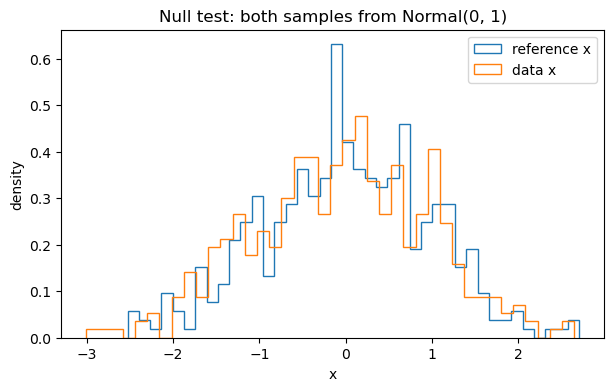

In [9]:

# Same Gaussian features, different weight distributions.
x_ref_null = make_gaussian(N_REF, mean=0.0, sigma=1.0, seed=10)
x_data_null = make_gaussian(N_DATA, mean=0.0, sigma=1.0, seed=11)

w_ref_null = make_independent_weights(N_REF, kind="lognormal", seed=20)
w_data_null = make_independent_weights(N_DATA, kind="two_level", seed=21)

print("ref weights: ", float(w_ref_null.min()), float(w_ref_null.mean()), float(w_ref_null.max()), float(w_ref_null.sum()))
print("data weights:", float(w_data_null.min()), float(w_data_null.mean()), float(w_data_null.max()), float(w_data_null.sum()))

plt.figure(figsize=(7, 4))
plt.hist(x_ref_null.numpy().ravel(), bins=40, histtype="step", density=True, label="reference x")
plt.hist(x_data_null.numpy().ravel(), bins=40, histtype="step", density=True, label="data x")
plt.title("Null test: both samples from Normal(0, 1)")
plt.xlabel("x")
plt.ylabel("density")
plt.legend()
plt.show()


Iteration 0 - penalty 1.000000e-06 - sub-iterations 1000
[KeOps] Generating code for formula Sum_Reduction(Exp(((Var(0,1,0)/Var(3,1,2)-Var(1,1,1)/Var(3,1,2))*Sum(Var(0,1,0)/Var(3,1,2)-Var(1,1,1)/Var(3,1,2)))*1/-2)*Var(2,1,1),0) ... OK
[pyKeOps] Compiling pykeops cpp e055707139 module ... OK
Iteration 0 - penalty 1.000000e-06 - sub-iterations 1000
Iteration 0 - penalty 1.000000e-06 - sub-iterations 1000
Iteration 0 - penalty 1.000000e-06 - sub-iterations 1000
Iteration 0 - penalty 1.000000e-06 - sub-iterations 1000
Iteration 0 - penalty 1.000000e-06 - sub-iterations 1000
Iteration 0 - penalty 1.000000e-06 - sub-iterations 1000
Iteration 0 - penalty 1.000000e-06 - sub-iterations 1000
Iteration 0 - penalty 1.000000e-06 - sub-iterations 1000
Iteration 0 - penalty 1.000000e-06 - sub-iterations 1000
Iteration 0 - penalty 1.000000e-06 - sub-iterations 1000
Iteration 0 - penalty 1.000000e-06 - sub-iterations 1000
Iteration 0 - penalty 1.000000e-06 - sub-iterations 1000
Iteration 0 - penalty 1.

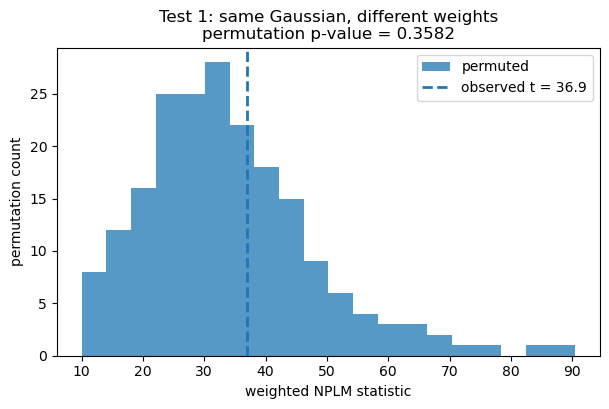

In [10]:

cfg_null = FitConfig(
    sigma=SIGMA,
    M=M,
    penalty_list=tuple(PENALTY_LIST),
    iter_list=tuple(ITER_LIST),
    fit_seed=777,
)

res_null = permutation_test_fixed_weight_slots(
    x_ref_null,
    x_data_null,
    w_ref_null,
    w_data_null,
    n_perm=N_PERM,
    cfg=cfg_null,
    seed=1000,
)

summarize_result(res_null, "Test 1: same Gaussian, different weights")
plot_permutation_result(res_null, "Test 1: same Gaussian, different weights")



## Test 2: shifted Gaussians, positive weights

The reference features are generated from `Normal(0, 1)`, while the data features are generated from `Normal(0.75, 1)`. The weights are still positive and independent of `x`.

Expected behavior: the observed statistic should lie in the high tail of the permutation distribution, giving a small p-value. With `N_PERM = 25`, the smallest possible p-value is `1 / 26 ≈ 0.038`. Increase `N_PERM` to resolve smaller p-values.


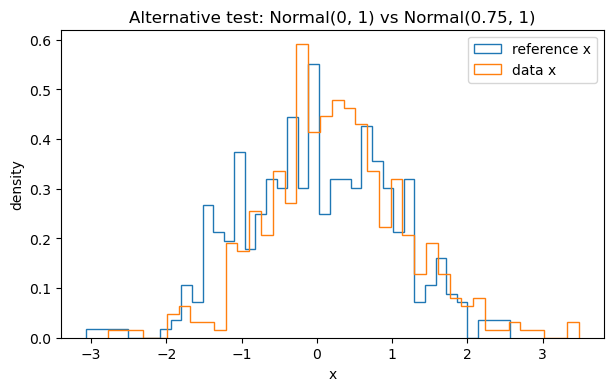

In [11]:

x_ref_alt = make_gaussian(N_REF, mean=0.0, sigma=1.0, seed=30)
x_data_alt = make_gaussian(N_DATA, mean=0.2, sigma=1.0, seed=31)

w_ref_alt = make_independent_weights(N_REF, kind="lognormal", seed=40)
w_data_alt = make_independent_weights(N_DATA, kind="two_level", seed=41)

plt.figure(figsize=(7, 4))
plt.hist(x_ref_alt.numpy().ravel(), bins=40, histtype="step", density=True, label="reference x")
plt.hist(x_data_alt.numpy().ravel(), bins=40, histtype="step", density=True, label="data x")
plt.title("Alternative test: Normal(0, 1) vs Normal(0.75, 1)")
plt.xlabel("x")
plt.ylabel("density")
plt.legend()
plt.show()


Iteration 0 - penalty 1.000000e-06 - sub-iterations 1000
Iteration 0 - penalty 1.000000e-06 - sub-iterations 1000
Iteration 0 - penalty 1.000000e-06 - sub-iterations 1000
Iteration 0 - penalty 1.000000e-06 - sub-iterations 1000
Iteration 0 - penalty 1.000000e-06 - sub-iterations 1000
Iteration 0 - penalty 1.000000e-06 - sub-iterations 1000
Iteration 0 - penalty 1.000000e-06 - sub-iterations 1000
Iteration 0 - penalty 1.000000e-06 - sub-iterations 1000
Iteration 0 - penalty 1.000000e-06 - sub-iterations 1000
Iteration 0 - penalty 1.000000e-06 - sub-iterations 1000
Iteration 0 - penalty 1.000000e-06 - sub-iterations 1000
Iteration 0 - penalty 1.000000e-06 - sub-iterations 1000
Iteration 0 - penalty 1.000000e-06 - sub-iterations 1000
Iteration 0 - penalty 1.000000e-06 - sub-iterations 1000
Iteration 0 - penalty 1.000000e-06 - sub-iterations 1000
Iteration 0 - penalty 1.000000e-06 - sub-iterations 1000
Iteration 0 - penalty 1.000000e-06 - sub-iterations 1000
Iteration 0 - penalty 1.000000e

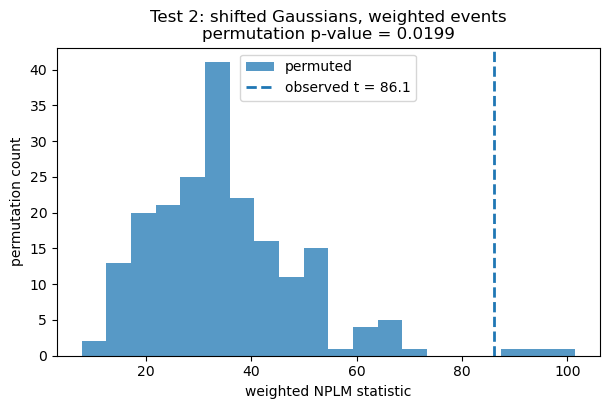

In [12]:

cfg_alt = FitConfig(
    sigma=SIGMA,
    M=M,
    penalty_list=tuple(PENALTY_LIST),
    iter_list=tuple(ITER_LIST),
    fit_seed=777,
)

res_alt = permutation_test_fixed_weight_slots(
    x_ref_alt,
    x_data_alt,
    w_ref_alt,
    w_data_alt,
    n_perm=N_PERM,
    cfg=cfg_alt,
    seed=2000,
)

summarize_result(res_alt, "Test 2: shifted Gaussians, weighted events")
plot_permutation_result(res_alt, "Test 2: shifted Gaussians, weighted events")



## Inspect the learned function on the alternative

For equal-variance Gaussians with means `mu_data` and `mu_ref`, the ideal log-density ratio is linear in `x`. With `mu_ref = 0` and `mu_data = 0.1`, the ideal slope is approximately `0.1` up to constants and regularization effects.


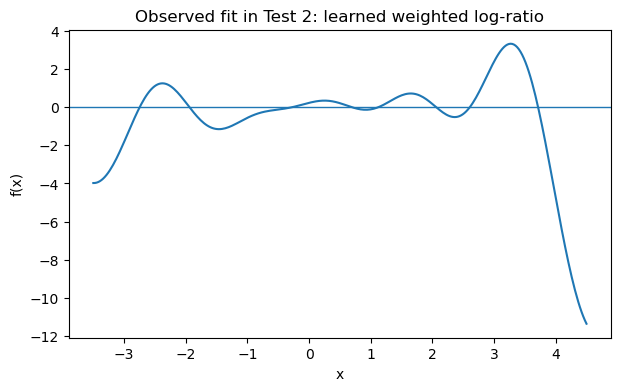

In [13]:

def plot_learned_function(result, x_min=-3.5, x_max=4.5, title="learned f(x)"):
    model = result["model_obs"]
    grid = torch.linspace(x_min, x_max, 300, dtype=DTYPE).reshape(-1, 1)
    with torch.no_grad():
        f_grid = model.predict(grid).reshape(-1).detach().cpu().numpy()
    plt.figure(figsize=(7, 4))
    plt.plot(grid.numpy().ravel(), f_grid)
    plt.axhline(0.0, linewidth=1)
    plt.xlabel("x")
    plt.ylabel("f(x)")
    plt.title(title)
    plt.show()


plot_learned_function(res_alt, title="Observed fit in Test 2: learned weighted log-ratio")



## Notes for interpreting failures

- If Test 1 gives a small p-value once, that can happen by chance. Re-run with a different seed or increase `N_PERM`.
- If Test 1 is **systematically** small, check that your weights are positive, class-wise normalized, and independent of `x`.
- If Test 2 is not small, increase the shift, increase `N_REF/N_DATA`, increase `M`, or increase the training iterations.
- If Falkon complains about CUDA, confirm that `FalkonOptions(use_cpu=True)` is being used.
- If `from nplm import EventWeightedCrossEntropyLoss` fails, run the notebook from the repo root or add the repo root to `sys.path` in the first cell.
